In [1]:
import pandas as pd

df = pd.read_csv('/content/IceCreamData.csv')
display(df.head())

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


In [2]:
from sklearn.model_selection import train_test_split

X = df[['Temperature']]
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (400, 1)
Testing features shape: (100, 1)
Training target shape: (400,)
Testing target shape: (100,)


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 21.38197385529505
Intercept: 46.80464127742374


In [4]:
y_pred = model.predict(X_test)

print("First 5 predictions:", y_pred[:5])
print("First 5 actual values:", y_test.head().values)

First 5 predictions: [681.93870622 632.14474995 559.64360486 498.90609993 615.45939165]
First 5 actual values: [659.8732869 623.2487008 559.1358692 497.7523178 627.9018411]


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 19.18
Mean Squared Error (MSE): 652.52
R-squared (R2) Score: 0.98


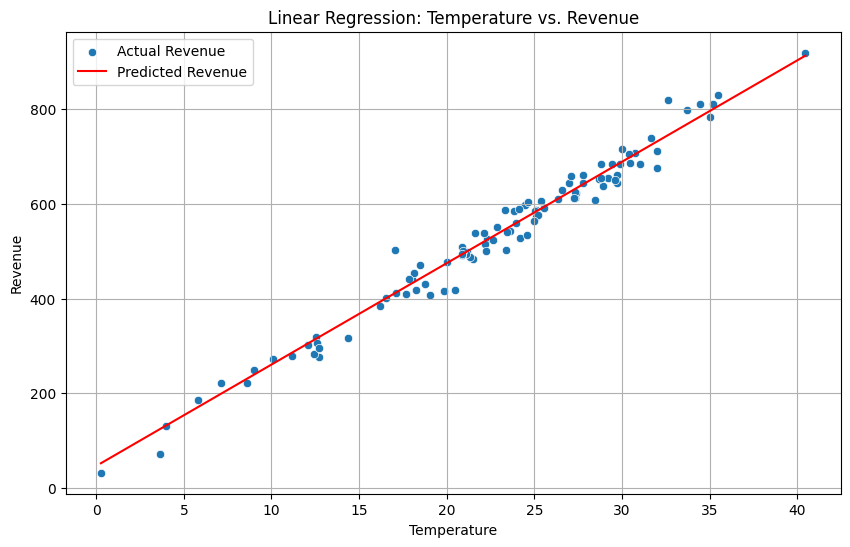

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['Temperature'], y=y_test, label='Actual Revenue')
sns.lineplot(x=X_test['Temperature'], y=y_pred, color='red', label='Predicted Revenue')
plt.title('Linear Regression: Temperature vs. Revenue')
plt.xlabel('Temperature')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)
plt.show()